# Sentinel-1 GRD Product: radiometric terrain correction

In [1]:
import os
import numpy as np
import xarray as xr
from xcube.core.store import new_data_store
from xcube_resampling import affine_transform_dataset
from xcube_resampling import rectify_dataset
from xcube_resampling.gridmapping import GridMapping
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt
import pystac_client
import rasterio
import rioxarray

xr.set_options(display_expand_attrs=False)

In [2]:
os.environ.update({
    "AWS_ACCESS_KEY_ID": "O0M0CUQIDQO9TDZ4D8NR",
    "AWS_SECRET_ACCESS_KEY": "qPUyXs9G6j8on6MY5KPhQNHuA5uZTqxEscrbBCGx",
    "AWS_S3_ENDPOINT": "eodata.dataspace.copernicus.eu",
    "AWS_VIRTUAL_HOSTING": "FALSE",   # 🔥 critical
})

In [3]:
cluster = LocalCluster(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="3.8GB",
    dashboard_address="8787",
)
client = Client(cluster)
client.dashboard_link

/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41917 instead
  warnings.warn(


'http://127.0.0.1:41917/status'

In [4]:
path = (
    "data/S1C_IW_GRDH_1SDV_20260331T043117_20260331T043142_007003_00E2E3_7002.zarr"
)

In [5]:
%%time
dt = xr.open_datatree(path, engine="zarr", chunks={})

CPU times: user 109 ms, sys: 6.99 ms, total: 116 ms
Wall time: 114 ms


In [6]:
dt.groups

('/',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/measurements',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/quality',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV/conditions',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV/measurements',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV/quality',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/antenna_pattern',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/attitude',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/doppler_centroid',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/gcp',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/orbit',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/quality/calibration',
 '/S01SIWGRD_202603

In [7]:
%%time
group_VH = [x for x in dt.children if "VH" in x][0]
grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
group_VV = [x for x in dt.children if "VV" in x][0]
grd["vv"] = dt[group_VV].measurements.to_dataset().grd
gcps = dt[group_VH].conditions.gcp.to_dataset()
gcps = gcps[["latitude", "longitude"]]
gcps_interp = gcps.interp(ground_range=grd.ground_range).chunk(dict(ground_range=2048))
gcps_interp = gcps_interp.interp(azimuth_time=grd.azimuth_time).chunk(dict(azimuth_time=2048))
grd = grd.assign_coords(dict(
    latitude=gcps_interp.latitude, 
    longitude=gcps_interp.longitude, 
))
grd

CPU times: user 22.3 ms, sys: 2.05 ms, total: 24.4 ms
Wall time: 23.6 ms


<xarray.Dataset> Size: 9GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) float64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
    latitude      (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

In [8]:
%%time
bbox = [
    grd.longitude.min().values.item(),
    grd.latitude.min().values.item(),
    grd.longitude.max().values.item(),
    grd.latitude.max().values.item(),
]
bbox

CPU times: user 9.83 s, sys: 2.01 s, total: 11.8 s
Wall time: 27.8 s


[21.051876068115234, 35.52719497680664, 24.24344253540039, 37.43724822998047]

In [9]:
%%time
STAC_URL = "https://stac.dataspace.copernicus.eu/v1"
client = pystac_client.Client.open(STAC_URL)
search = client.search(
    collections=["cop-dem-glo-30-dged-cog"],
    bbox=bbox,
)
items = list(search.items())
items

CPU times: user 28.3 ms, sys: 4.05 ms, total: 32.3 ms
Wall time: 243 ms


[<Item id=Copernicus_DSM_COG_10_N35_00_E023_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N37_00_E024_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N37_00_E023_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N36_00_E024_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N36_00_E023_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N35_00_E024_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N37_00_E022_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N37_00_E021_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N36_00_E022_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N36_00_E021_00_DEM>]

In [10]:
%%time
dss = []
for item in items: 
    dss.append(
        rioxarray.open_rasterio(
            item.assets["data"].href,
            chunks={},
            band_as_variable=True,
        )
    )
dem = xr.combine_by_coords(dss, join="outer", fill_value=0.)
dem = dem.rename({"band_1": "dem"})
dem

CPU times: user 515 ms, sys: 38.3 ms, total: 554 ms
Wall time: 2.26 s


<xarray.Dataset> Size: 622MB
Dimensions:      (y: 10800, x: 14400)
Coordinates:
  * y            (y) float64 86kB 38.0 38.0 38.0 38.0 ... 35.0 35.0 35.0 35.0
  * x            (x) float64 115kB 21.0 21.0 21.0 21.0 ... 25.0 25.0 25.0 25.0
    spatial_ref  int64 8B 0
Data variables:
    dem          (y, x) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
Attributes: (1)

CPU times: user 605 ms, sys: 139 ms, total: 744 ms
Wall time: 8.23 s


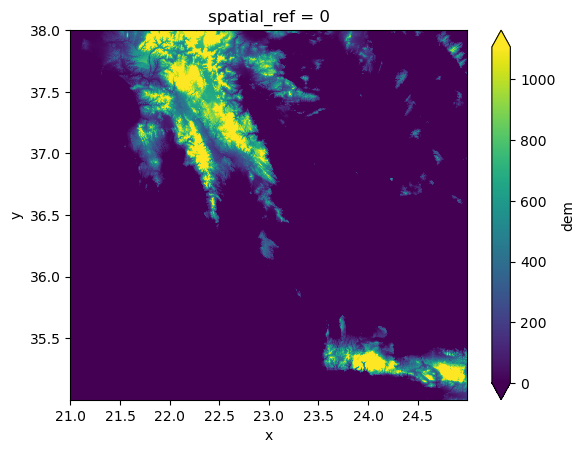

In [11]:
%%time
dem.dem[::10, ::10].plot(robust=True)